# Nutrient Uptake

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import sys
import os
# Add the directory containing model_utils.py to the Python path
sys.path.append('../models')
from pi_npz import PhysicsInformedNN, DNN, forward_pinn
from traditional_npz import rk4, npz_nl, run_rk4_for_initial_conditions
sys.path.append('../utils')
from additional_files import embedded_npz, calculate_rel_error, calculate_rmse

# RK4 for a single set of initial conditions
def run_rk4_embedded_npz(N0, P0, Z0, t, phi):
    # Define the initial conditions as a list
    x0 = [N0, P0, Z0]
    # Use the rk4 method to expand the system over time
    xt = rk4(embedded_npz, x0, t, None, 0, phi)
    return xt
    

In [3]:
# Define the parameters for the system
Vm = 2
ks = 1
m = 0.1
gamma = 0.3
Rm = 1.5
ivlev = 1
q = 0.2
phi = (Vm, ks, m, Rm, ivlev, gamma, q)

# Define the time parameters
tstart = 0  # Start time (day 0)
tend = 7 # End time (day 7)
minutes_per_step = 10  # Time step in minutes
minutes_per_hour = 60  # Constant time per hour
hours_per_day = 24  # Constant time per day
dt = minutes_per_step / (minutes_per_hour * hours_per_day)
t = np.arange(tstart, tend + dt, dt)  # Create the array of times

N0 = 1.6
P0 = 0.3
Z0 = 0.1

# Run RK4 with these initial conditions
original_npz = run_rk4_for_initial_conditions(N0, P0, Z0, t, phi)


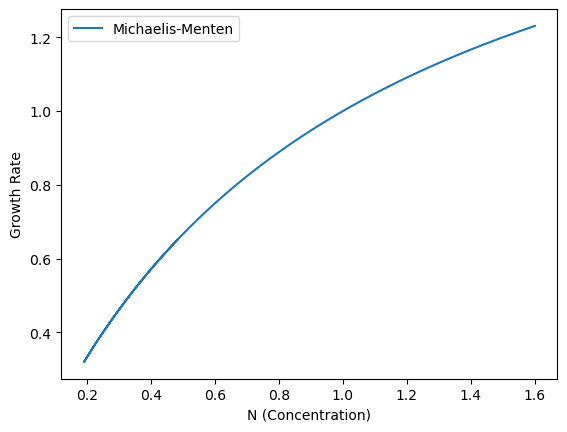

In [4]:
# Parameters for the Michaelis-Menten equation
Vm = 2.0  # Maximum growth rate
ks = 1.0  # Half-Saturation constant for nitrate

N_orig = original_npz[:, 0]

# Define the Michaelis-Menten function
def michaelis_menten(N, Vm, ks):
    return Vm * N / (ks + N)

MM_values = michaelis_menten(N_orig, Vm, ks)

# Plot the Michaelis-Menten function
plt.plot(N_orig, MM_values, label='Michaelis-Menten')
plt.xlabel('N (Concentration)')
plt.ylabel('Growth Rate')
plt.legend()
plt.show()


Pseudo Max Growth Rate (a): 1.2166
Pseudo Half-Saturation constant for nitrate (b): 1.2791


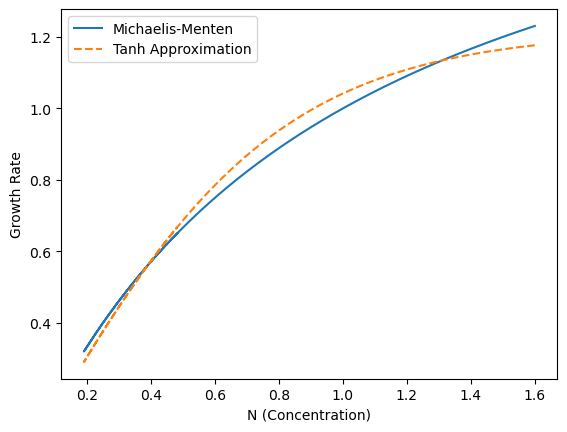

RMSE between tanh approximation and MM term: 0.023819


In [5]:
# Using hyperbolic tangent to approximate Michaelis-Menten (MM) dynamics
def tanh_approx(N, a, b):
    return a * np.tanh(b * N)

# Initial guess for the parameters
initial_guess = [Vm, ks]

# Fit the tanh function to the Michaelis-Menten data
mm_params, _ = curve_fit(tanh_approx, N_orig, MM_values, p0=initial_guess)

# Extract optimized parameters
a, b = mm_params
print(f"Pseudo Max Growth Rate (a): {a:.4f}")
print(f"Pseudo Half-Saturation constant for nitrate (b): {b:.4f}")
# Calculate the tanh approximation values
tanh_values = tanh_approx(N_orig, a, b)

# Plot Michaelis-Menten function vs. tanh approximation
plt.plot(N_orig, MM_values, label='Michaelis-Menten')
plt.plot(N_orig, tanh_values, label='Tanh Approximation', linestyle='--')
plt.xlabel('N (Concentration)')
plt.ylabel('Growth Rate')
plt.legend()


# === Save ===
# base_path = "../figures/"
# file_base = f"nutrient_uptake_approximation"

# # Save as vector format (PDF) for publication and PNG for review
# for ext in ["pdf"]:
#     if ext == "png":
#         dpi = 600  # High DPI for raster
#     else:
#         dpi = None  # Vector formats don't need DPI
#     plt.savefig(f"{base_path}{file_base}.{ext}", 
#                 dpi=dpi, 
#                 bbox_inches='tight', 
#                 pad_inches=0.02,
#                 format=ext)

plt.show()

# Compute RMSE
rmse_tanh = np.sqrt(np.mean((MM_values - tanh_values) ** 2))
print(f"RMSE between tanh approximation and MM term: {rmse_tanh:.6f}")


In [6]:
alpha = a
beta = b
b = 0.1
c = 0.2
e = 0.56
f = 0.44

phi_pinn = (alpha, beta, b, c, e, f)
# Run RK4 with these initial conditions
pinn_npz_result = run_rk4_embedded_npz(N0, P0, Z0, t, phi_pinn)


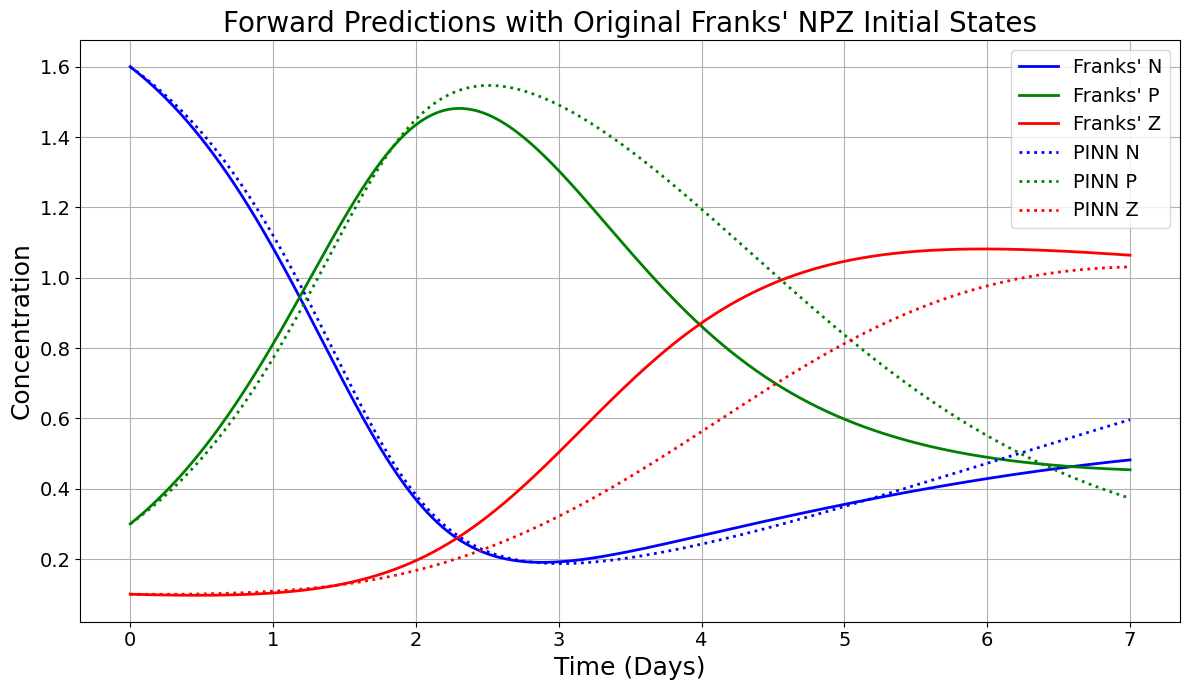

RMSE between Original Franks' and NN: 0.1405945900429134


In [7]:
total_days = 7 # / 24

intervals_per_day = 24 * 2 * 3 # 15 minute intervals (2 per hour)

# Calculate the total number of half-hour intervals
total_intervals = total_days * intervals_per_day

# Create an array from 0 to 7 days with half-hour intervals
times = np.arange(0, total_days + 1/intervals_per_day, 1/intervals_per_day)

if times[-1] > total_days:
    times = times[:-1]
# Plotting the results for the GELU model
output_names = ["N", "P", "Z"]
plt.figure(figsize=(12, 7))  # Slightly larger for presentations

# Plot actual values
len_plot = len(original_npz)
plt.plot(times, original_npz[:-1, 0], label="Franks' N", color='b', linewidth=2)
plt.plot(times, original_npz[:-1, 1], label="Franks' P", color='g', linewidth=2)
plt.plot(times, original_npz[:-1, 2], label="Franks' Z", color='r', linewidth=2)

plt.plot(times, pinn_npz_result[:-1, 0], label="PINN N", color='b', linestyle='dotted', linewidth=2)
plt.plot(times, pinn_npz_result[:-1, 1], label="PINN P", color='g', linestyle='dotted', linewidth=2)
plt.plot(times, pinn_npz_result[:-1, 2], label="PINN Z", color='r', linestyle='dotted', linewidth=2)

# Labels and title with increased font sizes
plt.xlabel('Time (Days)', fontsize=18)
plt.ylabel('Concentration', fontsize=18)
plt.title("Forward Predictions with Original Franks' NPZ Initial States", fontsize=20)

# Ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legend
plt.legend(fontsize=14)

# Grid and layout
plt.grid(True)
plt.tight_layout()

plt.show()

rmse_original_franks = calculate_rmse(pinn_npz_result, original_npz)
print(f"RMSE between Original Franks' and NN: {rmse_original_franks}")